In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [27]:
df = pd.read_csv('/content/car data.csv')
df.drop_duplicates(inplace=True)

# Ensure 'Year' exists before calculating 'Car_Age' and dropping it
if 'Year' in df.columns:
    df["Car_Age"] = 2026 - df["Year"]
    df.drop("Year", axis=1, inplace=True)

print(df.shape)

(299, 9)


In [4]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df["Car_Age"] = 2026 - df["Year"]

In [15]:
if "Year" in df.columns:
    df.drop("Year", axis=1, inplace=True)

In [25]:
le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

print(df.head())

  Car_Name  Selling_Price  Present_Price  Driven_kms  Fuel_Type  Selling_type  \
0     ritz           3.35           5.59       27000          2             0   
1      sx4           4.75           9.54       43000          1             0   
2     ciaz           7.25           9.85        6900          2             0   
3  wagon r           2.85           4.15        5200          2             0   
4    swift           4.60           6.87       42450          1             0   

   Transmission  Owner  
0             1      0  
1             1      0  
2             1      0  
3             1      0  
4             1      0  


In [16]:
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [17]:
df.describe()

,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,0.043189
std,5.082812,8.642584,38886.883882,0.247915
min,0.100000,0.320000,500.000000,0.000000
25%,0.900000,1.200000,15000.000000,0.000000
50%,3.600000,6.400000,32000.000000,0.000000
75%,6.000000,9.900000,48767.000000,0.000000
max,35.000000,92.600000,500000.000000,3.000000


In [19]:
print(df["Fuel_Type"].value_counts())

Fuel_Type
2    239
1     60
0      2
Name: count, dtype: int64


In [20]:
print(df["Transmission"].value_counts())

Transmission
1    261
0     40
Name: count, dtype: int64


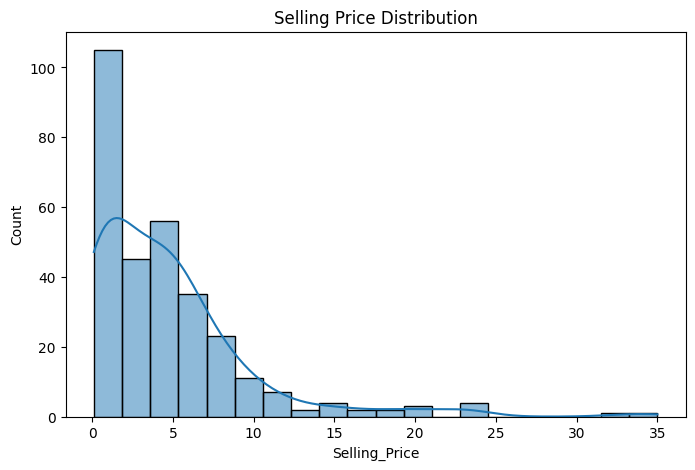

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Selling_Price"],
    bins=20,
    kde=True
)

plt.title("Selling Price Distribution")

plt.show()

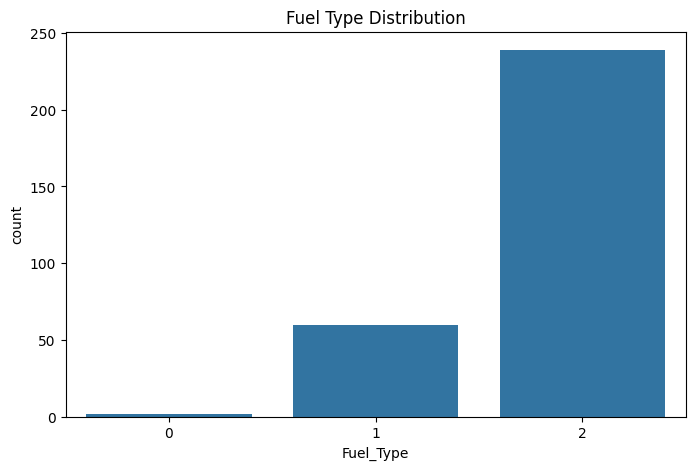

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Fuel_Type"]
)

plt.title("Fuel Type Distribution")

plt.show()

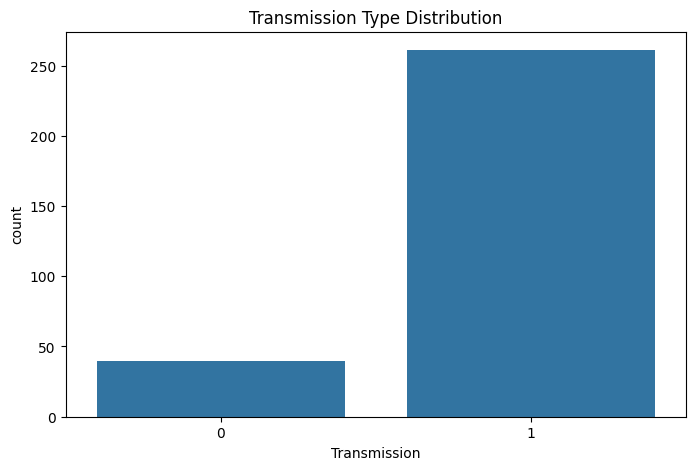

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Transmission"]
)

plt.title("Transmission Type Distribution")

plt.show()

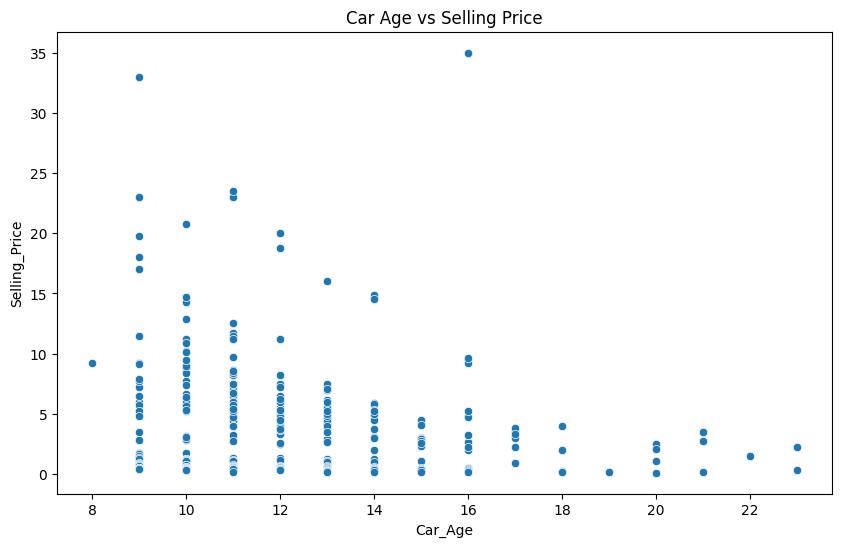

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price")

plt.show()

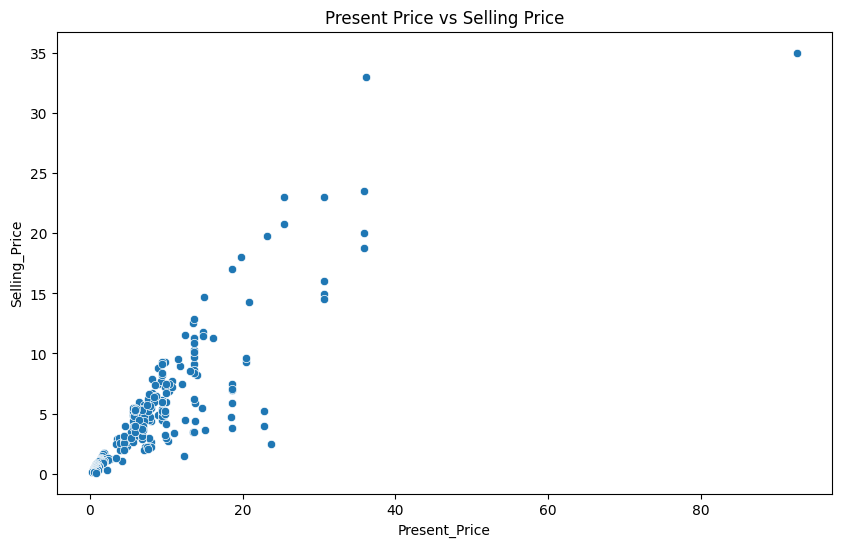

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")

plt.show()

In [30]:
le = LabelEncoder()

df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])

df["Selling_type"] = le.fit_transform(df["Selling_type"])

df["Transmission"] = le.fit_transform(df["Transmission"])

df["Car_Name"] = le.fit_transform(df["Car_Name"])

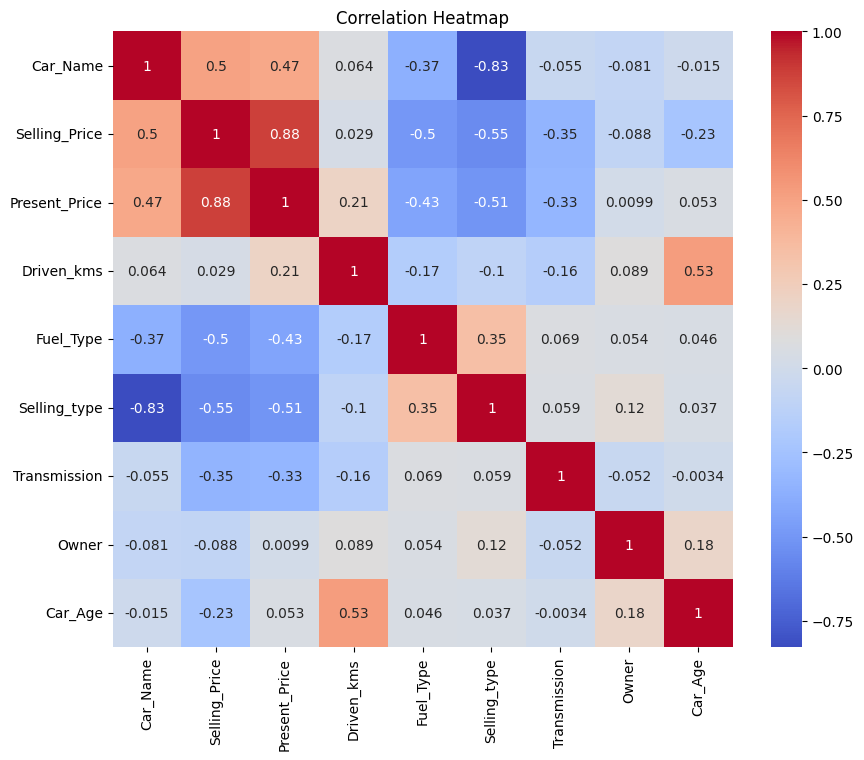

In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
X = df.drop("Selling_Price", axis=1)

In [33]:
y = df["Selling_Price"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [36]:
print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("MSE:",
      mean_squared_error(y_test, lr_pred))

print("R2 Score:",
      r2_score(y_test, lr_pred))

MAE: 1.571961002416831
MSE: 6.830668277841047
R2 Score: 0.7349707530639443


In [37]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [38]:
print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("MSE:",
      mean_squared_error(y_test, rf_pred))

print("R2 Score:",
      r2_score(y_test, rf_pred))

MAE: 1.2877233333333338
MSE: 9.995051112666669
R2 Score: 0.6121930151298915


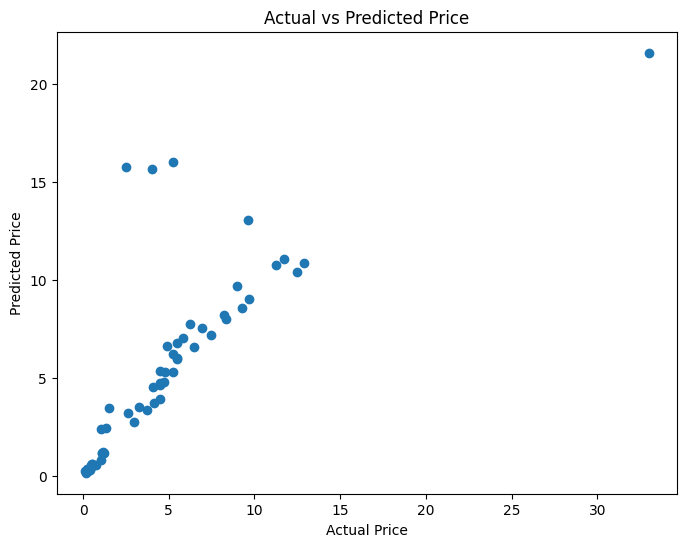

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [40]:
sample = [[
    50,      # Car_Name encoded
    5.5,     # Present Price
    30000,   # Driven Kms
    2,       # Fuel Type
    0,       # Selling Type
    1,       # Transmission
    0,       # Owner
    5        # Car Age
]]

prediction = rf.predict(sample)

print("Predicted Selling Price:", prediction)

Predicted Selling Price: [3.804]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [41]:
sample = [[
    50,      # Car_Name encoded
    5.5,     # Present Price
    30000,   # Driven Kms
    2,       # Fuel Type
    0,       # Selling Type
    1,       # Transmission
    0,       # Owner
    5        # Car Age
]]

prediction = rf.predict(sample)

print("Predicted Selling Price:", prediction)

Predicted Selling Price: [3.804]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
